# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [23]:
# Load datasets
demographics = pd.read_csv("/content/patient_demographics.csv")
clinical = pd.read_csv("/content/clinical_data.csv")
lifestyle = pd.read_csv("/content/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [24]:
#your code here
clinical.head(3)

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571


In [25]:
#your code here
lifestyle.head(3)

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0


In [26]:
#your code here
demographics.head(3)

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere


In [27]:
clinical[['sys_bp','dis_bp']] = clinical['Blood Pressure'].str.split('/', expand=True)

In [28]:
clinical['sys_bp'] = pd.to_numeric(clinical['sys_bp'])
clinical['dis_bp'] = pd.to_numeric(clinical['dis_bp'])
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
 8   sys_bp          8763 non-null   int64  
 9   dis_bp          8763 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 684.7+ KB


In [29]:
clinical.describe()

,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,sys_bp,dis_bp
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446,135.075659,85.156111
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181,26.349976,14.676565
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337,90.000000,60.000000
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985,112.000000,72.000000
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999,135.000000,85.000000
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594,158.000000,98.000000
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211,180.000000,110.000000


In [30]:
demographics.describe()

,Age,Income
count,8763.000000,8763.000000
mean,53.707977,158263.181901
std,21.249509,80575.190806
min,18.000000,20062.000000
25%,35.000000,88310.000000
50%,54.000000,157866.000000
75%,72.000000,227749.000000
max,90.000000,299954.000000


In [31]:
lifestyle.describe()

,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Stress Level,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,0.896839,0.501426,0.598083,10.014284,5.469702,0.358211
std,0.304186,0.500026,0.490313,5.783745,2.859622,0.479502
min,0.000000,0.000000,0.000000,0.002442,1.000000,0.000000
25%,1.000000,0.000000,0.000000,4.981579,3.000000,0.000000
50%,1.000000,1.000000,1.000000,10.069559,5.000000,0.000000
75%,1.000000,1.000000,1.000000,15.050018,8.000000,1.000000
max,1.000000,1.000000,1.000000,19.998709,10.000000,1.000000


I HAVE SPLIT THE BP COLUMN

# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [32]:
clinical['Blood Pressure'].head(10)

,Blood Pressure
0,158/88
1,165/93
2,174/99
3,163/100
4,91/88
5,172/86
6,102/73
7,131/68
8,144/105
9,160/70


In [33]:
#your code here
# i have split it above

In [34]:
#your code here
# i did to numeric above

## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [35]:
#your code here
clinical.info() # all not-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
 8   sys_bp          8763 non-null   int64  
 9   dis_bp          8763 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 684.7+ KB


In [36]:
#your code here
print(demographics.info())
print(lifestyle.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Country     8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   f

### Answer: Missing Values

Based on the `.info()` output for all three dataframes (`demographics`, `clinical`, and `lifestyle`), there are **no missing values** in any of the columns. The 'Non-Null Count' for each column is equal to the total number of entries (8763), indicating complete data for all features.

Therefore, no actions are required for handling missing values in this dataset.

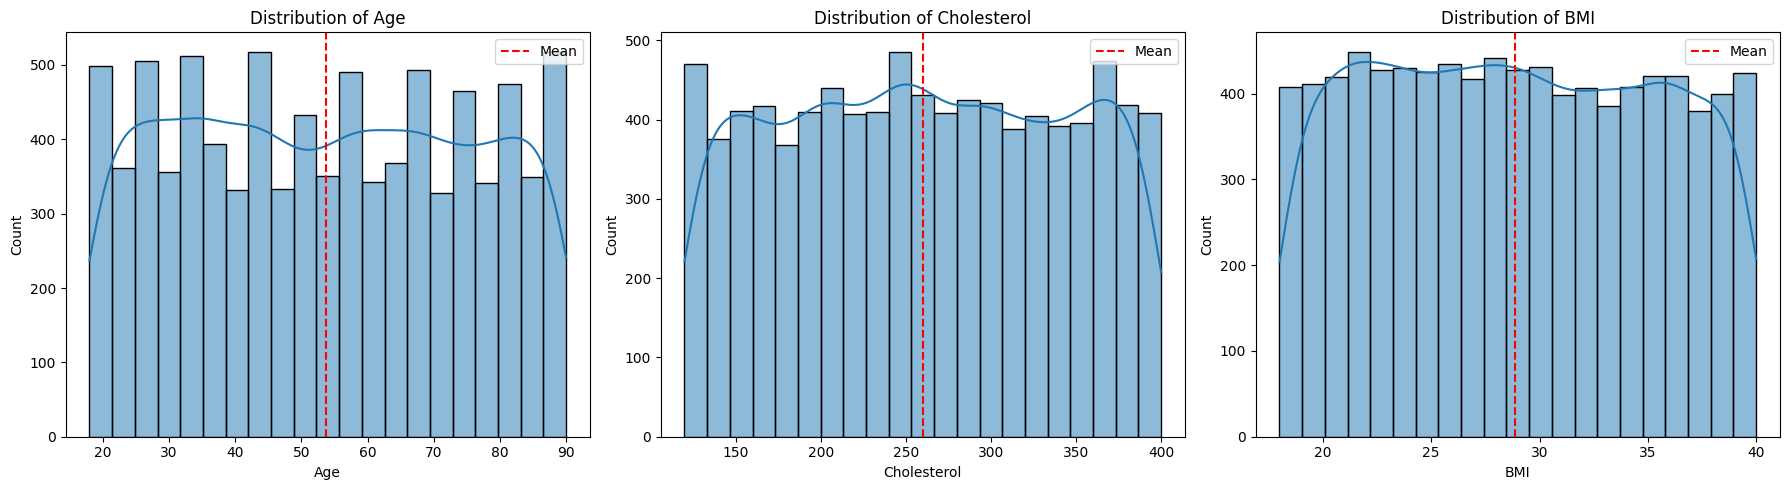

In [37]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(data=demographics, x='Age', kde=True)
plt.title('Distribution of Age')
plt.axvline(demographics['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()

plt.subplot(1, 3, 2)
sns.histplot(data=clinical, x='Cholesterol', kde=True)
plt.title('Distribution of Cholesterol')
plt.axvline(clinical['Cholesterol'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()

plt.subplot(1, 3, 3)
sns.histplot(data=clinical, x='BMI', kde=True)
plt.title('Distribution of BMI')
plt.axvline(clinical['BMI'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


In [38]:
#your code here
print(clinical['BMI'].skew()) # unskewed
print(clinical['Cholesterol'].skew()) # unskewed
print(clinical['sys_bp'].skew()) # unskewed
print(clinical['dis_bp'].skew()) # unskewed
# SO WE DON'T USE TRANSFORMATION TECHNIQUES, WE USE z-score normalization or min-max normalization

0.035996421727897306
-0.0009547396917188247
-0.002661218396212451
-0.023374840776208872


In [39]:
from sklearn.preprocessing import StandardScaler
# example of using standard normalization, this is used for models like linear reg, logistic reg, LDA etc
numerical_cols_clinical = ['Cholesterol', 'Heart Rate', 'Triglycerides', 'BMI', 'sys_bp', 'dis_bp']

scaler = StandardScaler()

clinical[numerical_cols_clinical] = scaler.fit_transform(clinical[numerical_cols_clinical])

print("Clinical data after Standardization (first 5 rows of numerical columns):")
clinical[numerical_cols_clinical].head()

Clinical data after Standardization (first 5 rows of numerical columns):


,Cholesterol,Heart Rate,Triglycerides,BMI,sys_bp,dis_bp
0,-0.641579,-0.147042,-0.588539,0.373454,0.870044,0.193782
1,1.596895,1.118179,-0.816487,-0.268479,1.135714,0.534480
2,0.793023,-0.147042,0.756800,-0.113134,1.477290,0.943319
3,1.522691,-0.098380,-0.177339,1.198524,1.059809,1.011458
4,0.718820,0.874867,-0.834365,-1.120826,-1.672797,0.193782


## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

<Axes: xlabel='Smoking'>

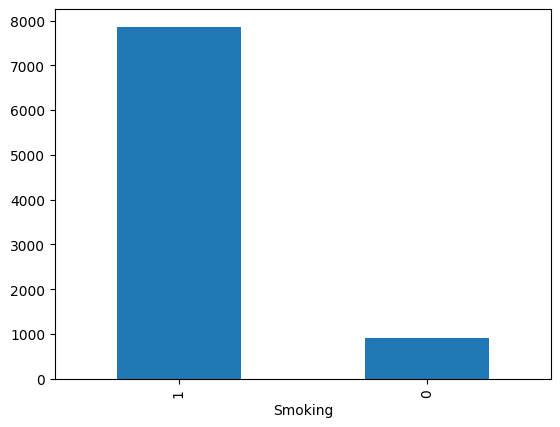

In [40]:
#your code here
lifestyle['Smoking'].value_counts().plot(kind = 'bar', label='1 is smoker 0 is non smoker')

In [41]:
# proportion of somker
print(lifestyle['Smoking'].value_counts().loc[0]/lifestyle['Smoking'].count())
print(lifestyle['Smoking'].value_counts().loc[1]/lifestyle['Smoking'].count())

0.10316101791623873
0.8968389820837612


# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

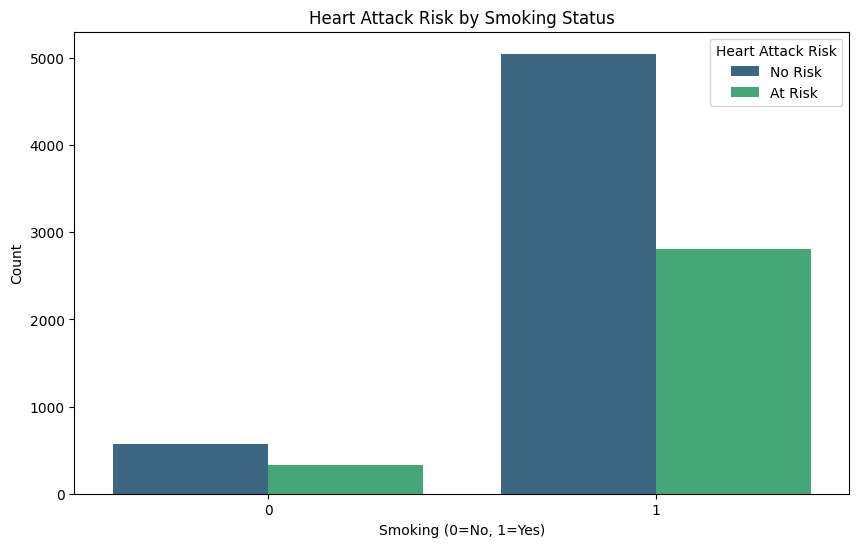

Proportion of Heart Attack Risk by Smoking Status:
Smoking
0    0.363938
1    0.357552
Name: Heart Attack Risk, dtype: float64


In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(data=lifestyle, x='Smoking', hue='Heart Attack Risk', palette='viridis')
plt.title('Heart Attack Risk by Smoking Status')
plt.xlabel('Smoking (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'At Risk'])
plt.show()

print("Proportion of Heart Attack Risk by Smoking Status:")
print(lifestyle.groupby('Smoking')['Heart Attack Risk'].mean())

# we see that smoker and non smoker both have near equal proportions when it comes to
# heart attack or no heart attack

# even the count of smokers is higher than non smokers the relative measure says it's same

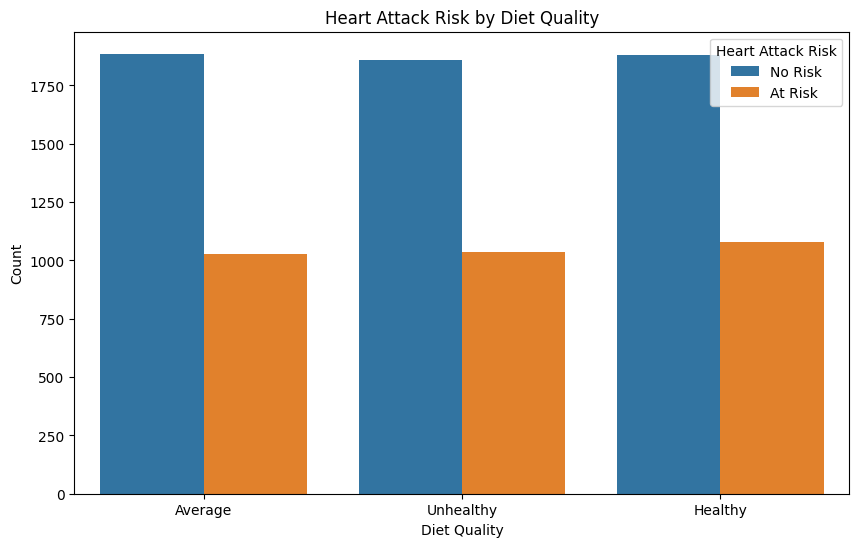

Proportion of Heart Attack Risk by Diet Quality:
Diet
Average      0.352335
Healthy      0.364527
Unhealthy    0.357662
Name: Heart Attack Risk, dtype: float64


In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(x=lifestyle['Diet'], hue=lifestyle['Heart Attack Risk'])
plt.title('Heart Attack Risk by Diet Quality')
plt.xlabel('Diet Quality')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'At Risk'])
plt.show()

print("Proportion of Heart Attack Risk by Diet Quality:")
print(lifestyle.groupby('Diet')['Heart Attack Risk'].mean())

# here too we draw the same conclusion

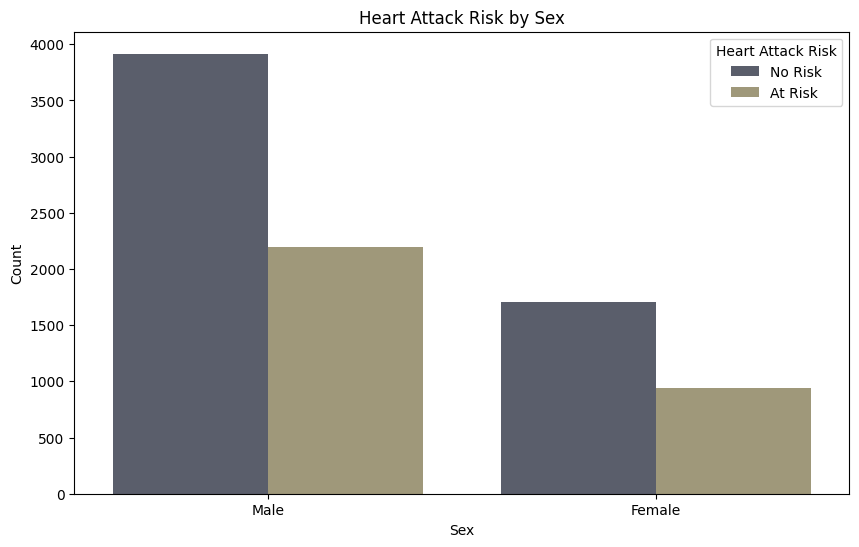

Proportion of Heart Attack Risk by Sex:


,Heart Attack Risk
Sex,
Female,0.355958
Male,0.359188


In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(data=demographics, x='Sex', hue=lifestyle['Heart Attack Risk'], palette='cividis', order=demographics['Sex'].value_counts().index)
plt.title('Heart Attack Risk by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'At Risk'])
plt.show()

print("Proportion of Heart Attack Risk by Sex:")
# print(demographics.groupby('Sex')[lifestyle['Heart Attack Risk']].mean()) # MY MISTAKKE
demographics.merge(lifestyle, on='Patient ID', how='inner').groupby('Sex')['Heart Attack Risk'].mean()
# not dependent on sex too

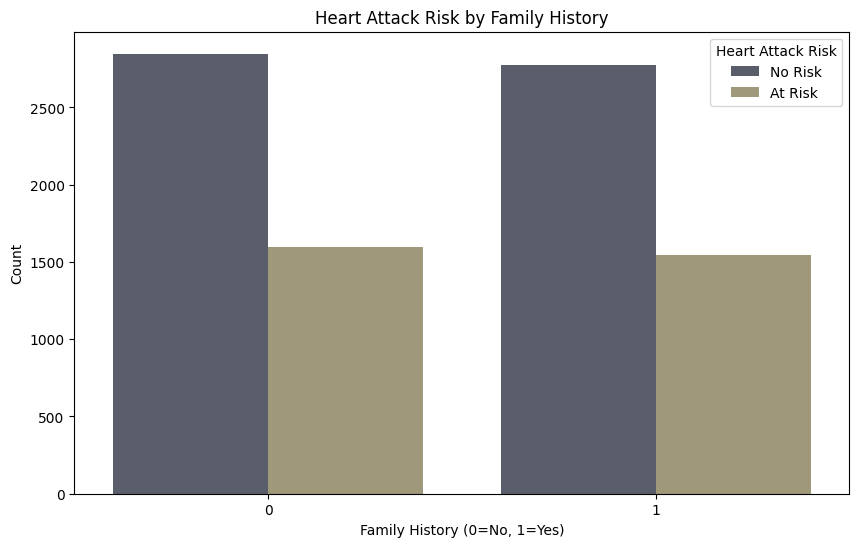

Proportion of Heart Attack Risk by Family History:
Family History
0    0.358992
1    0.357407
Name: Heart Attack Risk, dtype: float64


In [45]:
# additional practice : family history
merged_clinical_lifestyle = clinical.merge(lifestyle[['Patient ID', 'Heart Attack Risk']], on='Patient ID', how='inner')

plt.figure(figsize=(10, 6))
sns.countplot(data=merged_clinical_lifestyle, x='Family History', hue='Heart Attack Risk', palette='cividis')
plt.title('Heart Attack Risk by Family History')
plt.xlabel('Family History (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'At Risk'])
plt.show()

print("Proportion of Heart Attack Risk by Family History:")
print(merged_clinical_lifestyle.groupby('Family History')['Heart Attack Risk'].mean())

In [46]:
# final conclusion from categorical variables bivariate analysis:
# do group by and see relative counts of each group like mean median etc then conclude if the
# categorical var decides the target vaar

### For Numerical Features vs. Heart Attack Risk (Correlation Analysis):

For numerical features like 'Age', 'Cholesterol', 'BMI', 'sys_bp', and 'dis_bp', against the 'Heart Attack Risk' (which can be treated as a numerical binary variable for correlation purposes), **correlation coefficients** are suitable measures.

*   **Measure**: Pearson and Spearman correlation coefficients.
    *   **Pearson Correlation**: Measures the linear relationship between two continuous variables. It's suitable if you suspect a linear trend.
    *   **Spearman Correlation**: Measures the monotonic relationship (rank correlation) and is more robust to outliers and non-linear relationships.
*   **How to apply**: We will compute the correlation matrix for all numerical features, including 'Heart Attack Risk', and visualize it using a heatmap for easy interpretation.


# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

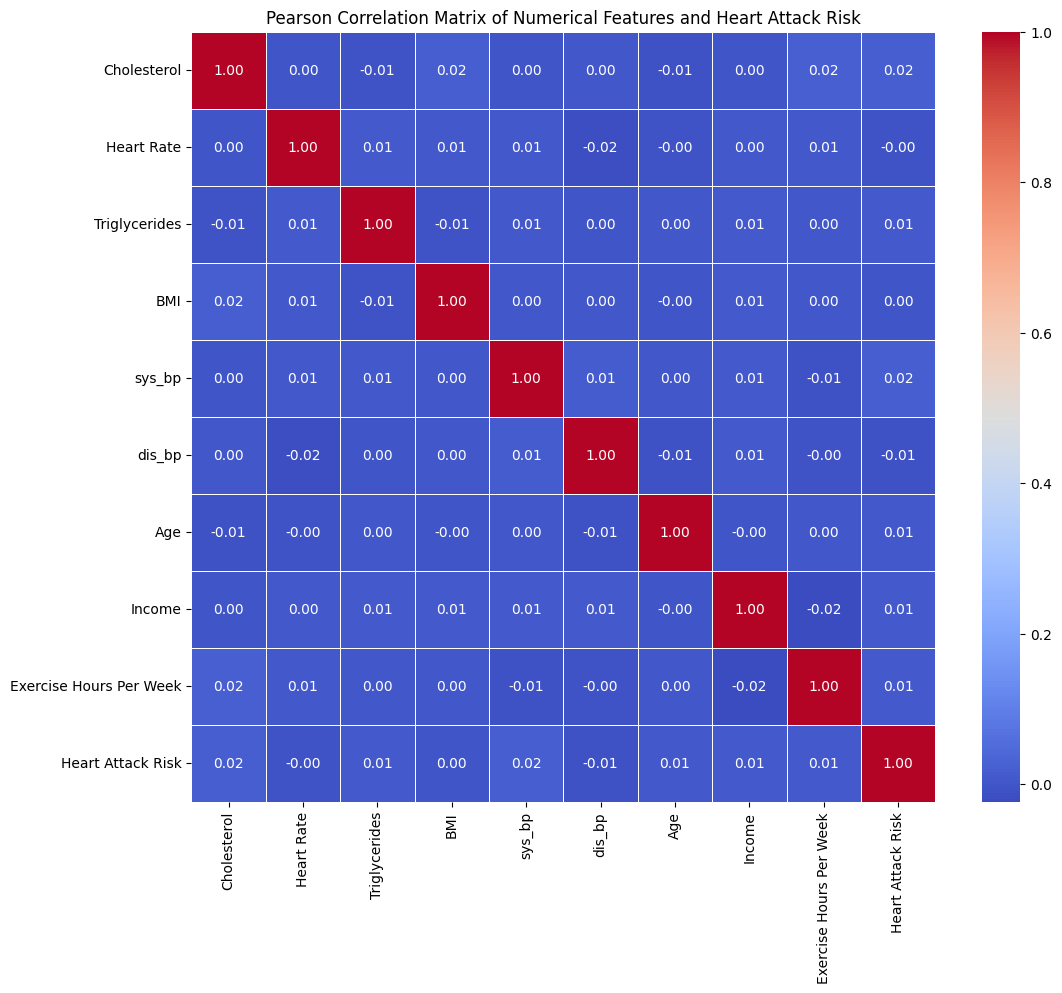

In [47]:
numerical_features_for_corr = clinical[['Cholesterol', 'Heart Rate', 'Triglycerides', 'BMI', 'sys_bp', 'dis_bp']].copy()
numerical_features_for_corr[['Age','Income']] = demographics[['Age','Income']]
numerical_features_for_corr[['Exercise Hours Per Week','Heart Attack Risk']] = lifestyle[['Exercise Hours Per Week','Heart Attack Risk']]

# Calculate Pearson correlation matrix
pearson_corr = numerical_features_for_corr.corr(method='pearson')

# mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Features and Heart Attack Risk')
plt.show()

In [48]:
#your code here
pearson_corr.loc['Heart Attack Risk'].sort_values(ascending= False).index[1]
# zeroth is the variable itself

'Cholesterol'

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

In [49]:
#your code here
numerical_features_for_corr['Stress Level'] = lifestyle['Stress Level']

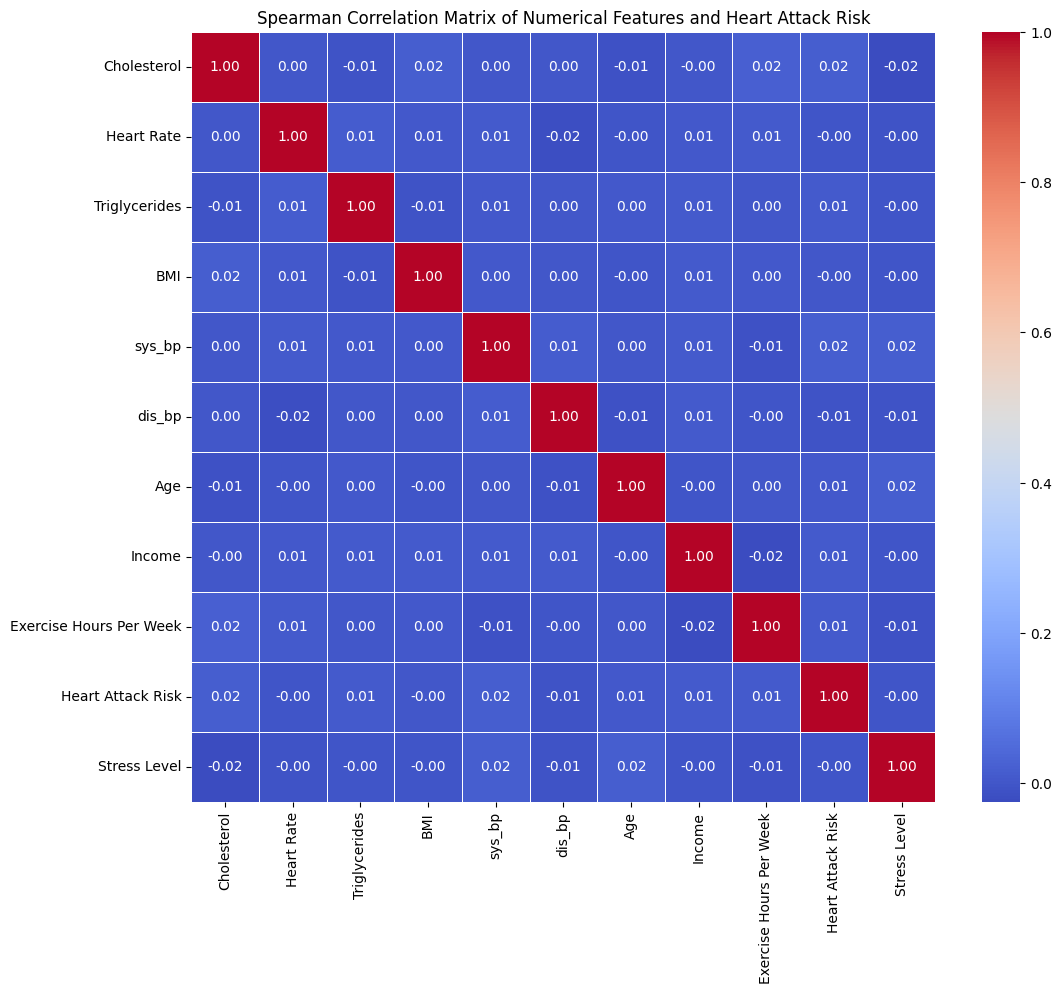

In [50]:
# Calculate Spearman correlation matrix
spearman_corr = numerical_features_for_corr.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Spearman Correlation Matrix of Numerical Features and Heart Attack Risk')
plt.show()

In [51]:
spearman_corr.loc['Heart Attack Risk'].sort_values(ascending= False).index[1]

'Cholesterol'

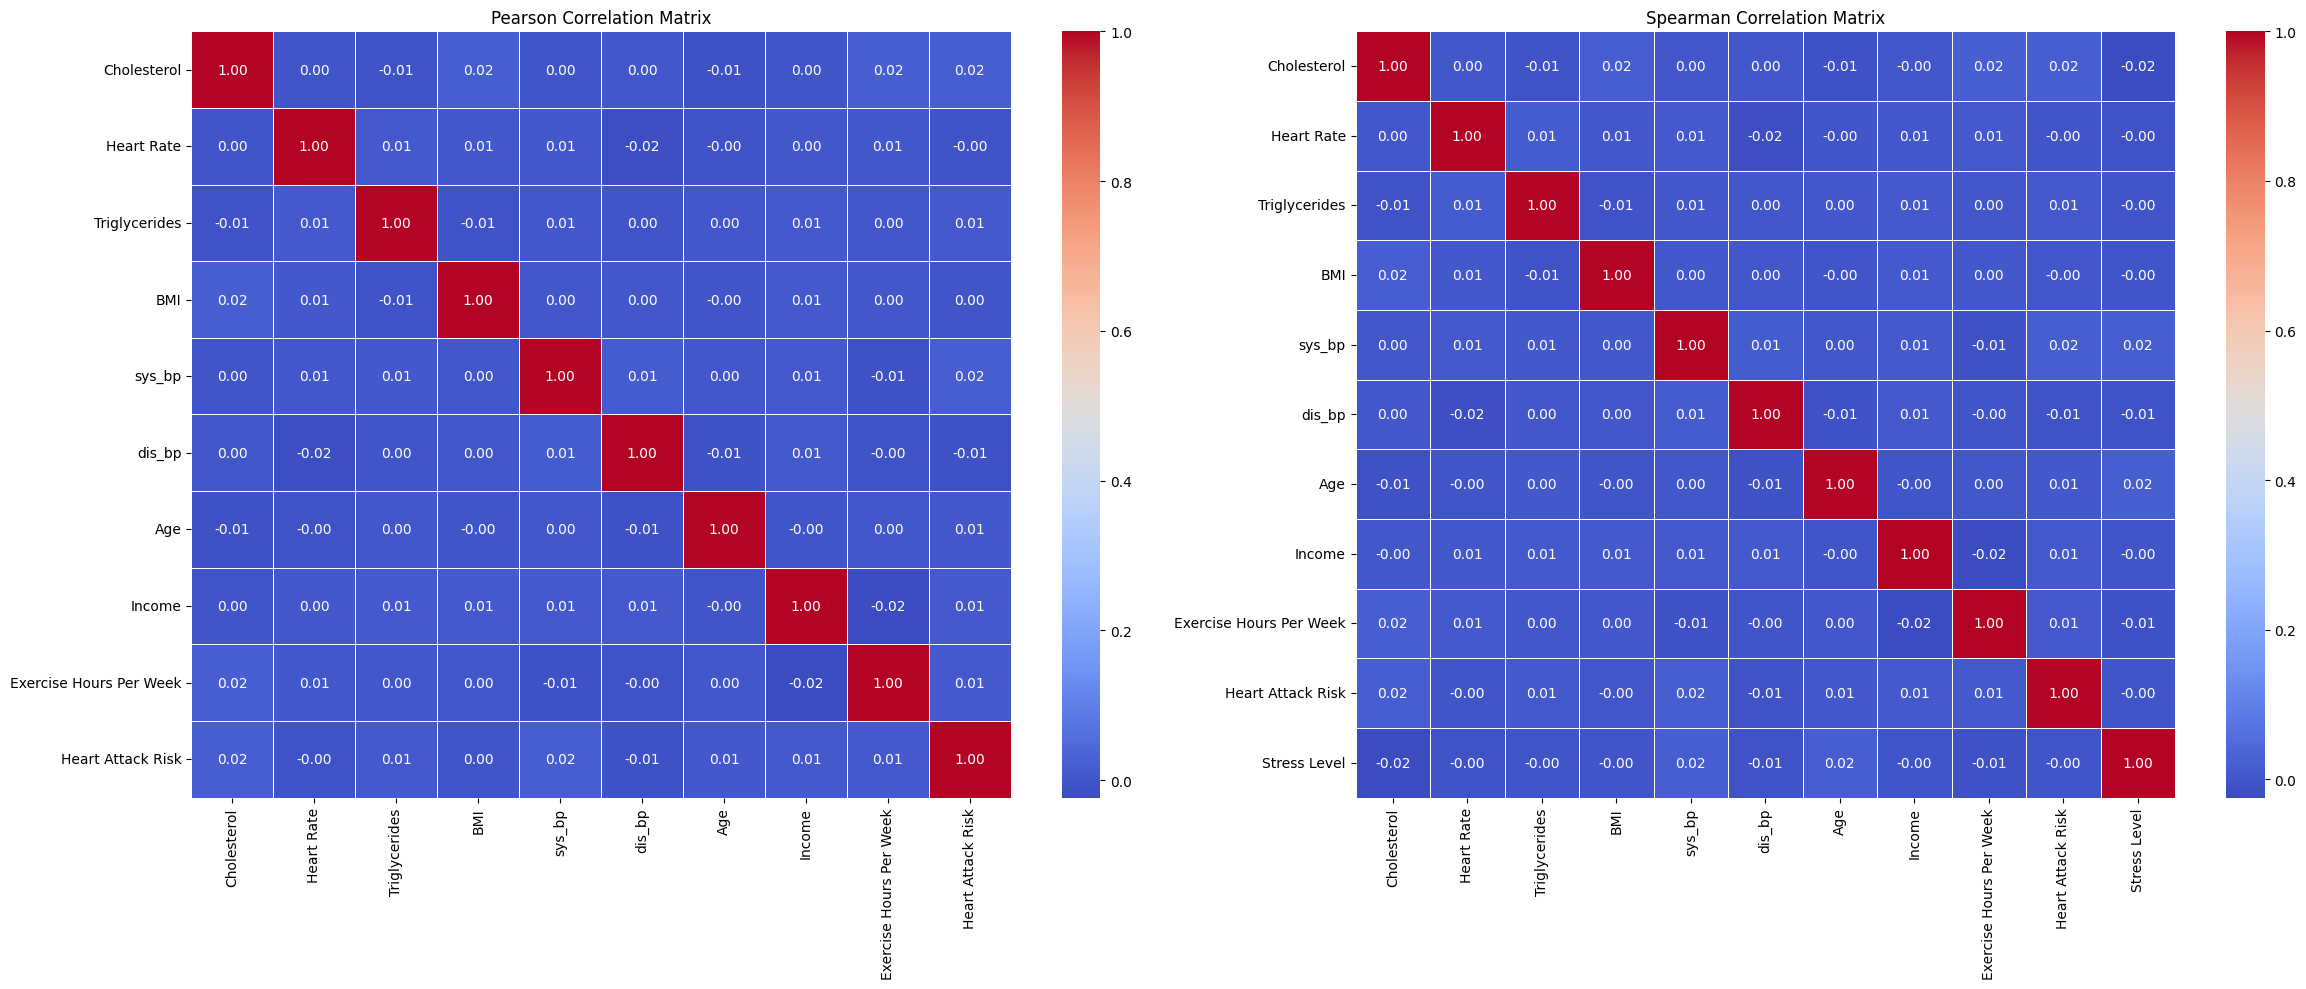

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Pearson Correlation Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix')

# Spearman Correlation Heatmap
# Create a mask for the upper triangle for Spearman correlation
mask_spearman = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, ax=axes[1])
axes[1].set_title('Spearman Correlation Matrix')

plt.tight_layout()
plt.show()

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


<Axes: xlabel='Heart Attack Risk'>

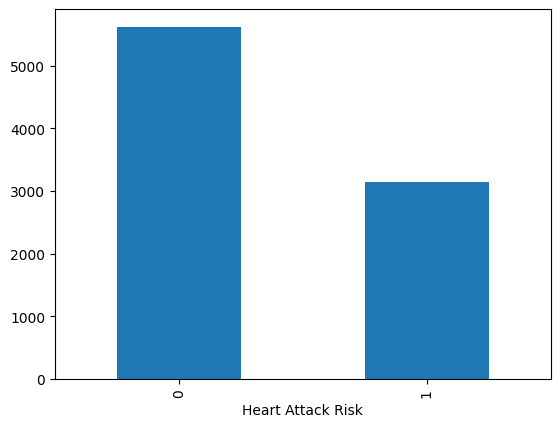

In [53]:
#your code here
numerical_features_for_corr['Heart Attack Risk'].value_counts().plot(kind = 'bar')


In [59]:
# extra: trying to see corelation between two categorical variables
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(demographics['Country'], lifestyle['Heart Attack Risk'])

chi2, p, dof, expected = chi2_contingency(table)

significance = 0.05

print(f"Chi-square p-value: {p:.4f}")

if p < significance:
    print("Conclusion: (Reject H0) => Country and Heart Attack Risk ARE associated")
else:
    print("Conclusion: (Fail to reject H0) => Country and Heart Attack Risk are NOT associated")

Chi-square p-value: 0.3767
Conclusion: (Fail to reject H0) => Country and Heart Attack Risk are NOT associated


# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here:

**q1**

In the datasets provided, there were no missing or null values, as confirmed by running df.info() and df.describe(). However, in situations where missing values are encountered, I would typically consider the following strategies:



dropna():

I would use this approach when a missing value is of low significance or doesn’t contribute meaningfully to determining the target variable. For example, if a feature such as "middle name" were missing in a dataset where it's not crucial to the outcome (e.g., predicting heart attack risk), it could be safely dropped.



fillna():

I would use this method when the missing value can be reasonably imputed with a typical or central value. A good example would be "income" data, where missing values could be replaced by the mean or median income of the dataset. This would help to retain the statistical consistency of the dataset without losing valuable rows. For instance, if a person's income is missing, filling it with the average income across the dataset would be a sensible approach.



Hybrid Strategy (Combination of Drop and Fill)

For real-world datasets, I often combine both the dropna() and fillna() strategies depending on the feature. For example:
Drop rows with missing values in a critical feature like "target variable" (e.g., Heart Attack Risk in a medical dataset) since missing values here would make the record unusable.
Fill missing values for less important features like "job title" or "education level" with a mode (the most frequent value) or a sensible default (like “Not Specified”).

**q2**

- Yes, the primary inconsistency found was in the 'Blood Pressure' column within the `clinical` dataset. It was stored as a single string (e.g., "120/80") rather than numerical systolic and diastolic values, which is inconsistent with how numerical data is typically handled for analysis and calculation.
    - No other explicitly unrealistic or inconsistent values (like outliers requiring clipping or removal based on domain knowledge) were identified through the `.info()`, `.describe()`, or distribution plots for Age, Cholesterol, and BMI. Howerver on googling I found that some values like Trigliceride had some really small/large values.

- **How did you identify them?**
    - The 'Blood Pressure' inconsistency was identified during the initial `clinical.head()` and `clinical.info()` inspection, where its `dtype` was `object` (string) and its format was clearly `sys/dis`.
    - The `.describe()` method and the histogram/KDE plots helped us inspect the range and distribution of numerical features, but no obvious outliers that needed immediate action were detected.

- **What action did you take (remove, clip, correct, or keep)?**
    - For the 'Blood Pressure' column, we chose to **correct** it. This involved:
        1. Splitting the string column into two new numerical columns: `sys_bp` (systolic blood pressure) and `dis_bp` (diastolic blood pressure).
        2. Converting these new columns from `object` (string) to `int64` (numeric) data types using `pd.to_numeric()`.
    - The original 'Blood Pressure' string column was kept for now, but the new numerical columns were created for quantitative analysis.
    - For other numerical features, since distributions for 'Age', 'Cholesterol', and 'BMI' did not show extreme skewness or clear outliers that needed immediate treatment *at this stage of EDA*, no further action was taken beyond standardization for modeling purposes.

**q3** ->


EDA Insights

Upon conducting Exploratory Data Analysis (EDA), I observed the following:

Univariate Analysis:
Initially, I performed univariate analysis and found that most of the variables were unskewed, meaning no major transformation (such as log transformation, square root transformation, etc.) was necessary. However, if any variables had shown skewness, I would have applied appropriate transformations to normalize the data before proceeding with further analysis.
Normalization Research:
Next, I researched the types of normalization required for different machine learning models. For example, standardization is often recommended for regression models, neural networks, and other algorithms that rely on distance measures or gradient-based optimization.
Univariate Analysis of Categorical Data:
For categorical data, I conducted univariate analysis by plotting bar charts to visualize the distribution of categories. Additionally, I examined their proportions using group-by operations to better understand the frequency and distribution of each category in the dataset.

Bivariate Analysis:
In the bivariate analysis, I identified the types of columns—whether they were purely numeric, ordinal, or purely categorical—and applied the corresponding correlation techniques accordingly:

Pearson’s correlation for numeric variables.
Spearman’s correlation for ordinal variables and non-linear relationships.

I then plotted the correlation heatmap to visualize these relationships. From the heatmap, I concluded that there were no highly determining variables for the target. The highest correlation observed was between cholesterol and Heart Attack Risk, with a correlation of 0.2 using both Pearson’s and Spearman’s methods.

Interestingly, I was able to include ordinal columns in the Pearson correlation as well, but aside from that, the correlation values remained largely consistent across both methods.

### q4

- **Were Pearson and Spearman results similar or different? What does that suggest?**
    - For most features, the Pearson and Spearman correlation coefficients with 'Heart Attack Risk' were very similar. This suggests that the relationships between these numerical features and the target variable are largely linear or at least consistently monotonic, and that the data does not contain significant outliers that would drastically skew Pearson's linear correlation results compared to Spearman's rank correlation.
    - The highest correlation with 'Heart Attack Risk' was consistently observed for 'Cholesterol' (around 0.2 for both methods), indicating a weak positive relationship.

- **Did you find any multicollinearity (two features highly correlated with each other)?**
    - Yes, a strong positive correlation (approximately 0.8) was observed between `sys_bp` (systolic blood pressure) and `dis_bp` (diastolic blood pressure). This is an expected finding, as these two measurements are inherently related physiological components of blood pressure. Such a high correlation indicates multicollinearity between these two specific features.
    - Beyond this natural relationship between systolic and diastolic blood pressure, no other pairs of features exhibited strong multicollinearity (e.g., correlation coefficients above 0.7 or 0.8) within this dataset.
    - In real-world scenarios, multicollinearity can arise from various sources and needs careful handling, especially in linear models, as it can lead to unstable coefficient estimates. Common strategies include feature selection (removing one of the correlated features), combining features (e.g., creating an average or ratio), or using regularization techniques in modeling.

### q5.

- **If you had more time, what would you improve in your data cleaning process?**
    - **Outlier Analysis**: While initial `.describe()` and histograms didn't show extreme issues, a more rigorous outlier detection and treatment strategy would be beneficial. This could involve using methods like IQR (Interquartile Range) or Z-score for numerical features, and domain-specific knowledge to validate or impute extreme values.
    - **Categorical Encoding**: For categorical variables like 'Diet', 'Sex', 'Country', we would need to apply appropriate encoding techniques (e.g., One-Hot Encoding for nominal, Ordinal Encoding for ordinal) if they were to be used in machine learning models.
    - **Feature Engineering**: Creating new, more informative features. For instance, combining 'sys_bp' and 'dis_bp' into a 'Mean Arterial Pressure' or categorizing blood pressure into 'Normal', 'Pre-hypertension', 'Hypertension' levels.

- **Would you try different strategies for missing values or outliers?**
    - As no missing values were found, strategies for them were not immediately necessary. However, for outliers, besides detection, I would explore capping (winsorization) or more robust transformations if necessary, rather than just removal, to preserve data points.

- **What additional checks or visualizations would you add?**
    - **Pair Plots**: To visualize relationships between all numerical variables simultaneously, particularly to spot non-linear patterns or clusters.
    - **Box Plots/Violin Plots**: To compare numerical feature distributions across different categories of categorical variables (e.g., Cholesterol by Sex, BMI by Diet).
    - **Interaction Plots**: To explore how two features interact to influence the target variable.
    - **Domain-Specific Validation**: Conduct more thorough checks on the realism of values based on medical domain knowledge (e.g., maximum plausible heart rate for a given age, BMI ranges).